# Análise Exploratória dos Microdados COVID-19 ES

## Atividade - Business Intelligence


Aluno: Pedro Henrique Ferreira Bonela  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('MICRODADOS.csv', sep=';', encoding='latin-1', low_memory=False)
print(f'Total de registros: {len(df):,}')
print(f'Colunas: {list(df.columns)}')
df.head()

Total de registros: 5,189,864
Colunas: ['DataNotificacao', 'DataCadastro', 'DataDiagnostico', 'DataColeta_RT_PCR', 'DataColetaTesteRapido', 'DataColetaSorologia', 'DataColetaSorologiaIGG', 'DataEncerramento', 'DataObito', 'Classificacao', 'Evolucao', 'CriterioConfirmacao', 'StatusNotificacao', 'Municipio', 'Bairro', 'FaixaEtaria', 'IdadeNaDataNotificacao', 'Sexo', 'RacaCor', 'Escolaridade', 'Gestante', 'Febre', 'DificuldadeRespiratoria', 'Tosse', 'Coriza', 'DorGarganta', 'Diarreia', 'Cefaleia', 'ComorbidadePulmao', 'ComorbidadeCardio', 'ComorbidadeRenal', 'ComorbidadeDiabetes', 'ComorbidadeTabagismo', 'ComorbidadeObesidade', 'FicouInternado', 'ViagemBrasil', 'ViagemInternacional', 'ProfissionalSaude', 'PossuiDeficiencia', 'MoradorDeRua', 'ResultadoRT_PCR', 'ResultadoTesteRapido', 'ResultadoSorologia', 'ResultadoSorologia_IGG', 'TipoTesteRapido']


,DataNotificacao,DataCadastro,DataDiagnostico,DataColeta_RT_PCR,DataColetaTesteRapido,DataColetaSorologia,DataColetaSorologiaIGG,DataEncerramento,DataObito,Classificacao,...,ViagemBrasil,ViagemInternacional,ProfissionalSaude,PossuiDeficiencia,MoradorDeRua,ResultadoRT_PCR,ResultadoTesteRapido,ResultadoSorologia,ResultadoSorologia_IGG,TipoTesteRapido
0,2026-03-27,2026-03-27,Mar 26 2026 12:00AM,2026-03-27,2026-03-27,NaN,NaN,NaN,NaN,Síndrome Gripal não Especificada,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno
1,2026-03-27,2026-03-27,Mar 26 2026 12:00AM,NaN,2026-03-26,NaN,NaN,2026-03-27,NaN,Descartados,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno
2,2026-03-27,2026-03-27,Mar 24 2026 12:00AM,NaN,2026-03-27,NaN,NaN,2026-03-27,NaN,Descartados,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno
3,2026-03-27,2026-03-27,Mar 27 2026 12:00AM,NaN,2026-03-27,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno
4,2026-03-27,2026-03-27,Mar 25 2026 12:00AM,NaN,2026-03-27,NaN,NaN,NaN,NaN,Suspeito,...,Não,Não,Não,Não,Não,Não Informado,Negativo,Não Informado,Não Informado,Teste rápido Antígeno


### Exercício 1 — Visão Geral do Dataset
Análise inicial do dataset, verificando dimensões, tipos de dados e valores nulos.

In [18]:
print("Dimensão do Dataset")
print(df.shape)

print("\nTipos de Dados")
print(df.dtypes)

print("\nValores Nulos")
print(df.isnull().sum())

Dimensão do Dataset
(5189864, 46)

Tipos de Dados
DataNotificacao            datetime64[ns]
DataCadastro                       object
DataDiagnostico                    object
DataColeta_RT_PCR                  object
DataColetaTesteRapido              object
DataColetaSorologia                object
DataColetaSorologiaIGG             object
DataEncerramento                   object
DataObito                          object
Classificacao                      object
Evolucao                           object
CriterioConfirmacao                object
StatusNotificacao                  object
Municipio                          object
Bairro                             object
FaixaEtaria                        object
IdadeNaDataNotificacao             object
Sexo                               object
RacaCor                            object
Escolaridade                       object
Gestante                           object
Febre                              object
DificuldadeRespiratoria   

### Exercício 2 — Distribuição por Classificação
Análise da frequência das classificações dos casos.

Classificacao
Descartados                         3253388
Confirmados                         1398338
Suspeito                             393027
Síndrome Gripal não Especificada     145111
Name: count, dtype: int64
Classificacao
Descartados                         62.687346
Confirmados                         26.943635
Suspeito                             7.572973
Síndrome Gripal não Especificada     2.796046
Name: proportion, dtype: float64


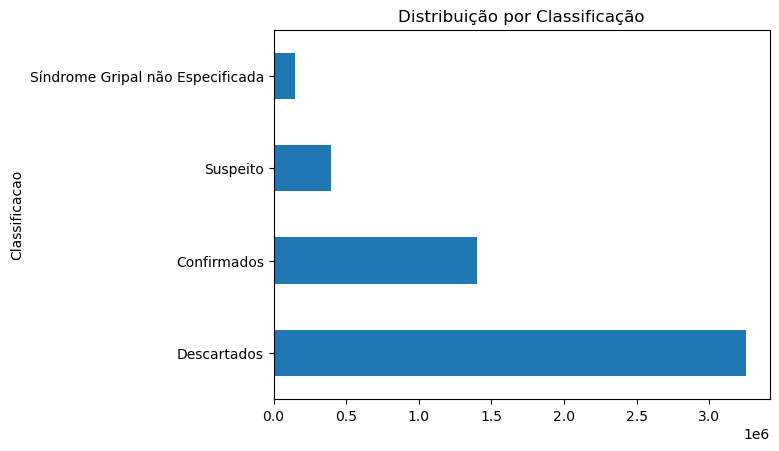

In [4]:
classificacao = df['Classificacao'].value_counts()
percentual = df['Classificacao'].value_counts(normalize=True) * 100

print(classificacao)
print(percentual)

classificacao.plot(kind='barh')
plt.title('Distribuição por Classificação')
plt.show()

Observa-se que a maioria dos registros está classificada como "Descartados", seguida pelos casos "Confirmados", que também representam uma parcela relevante. Já as categorias "Suspeito" e "Síndrome Gripal não Especificada" possuem menor frequência, indicando que a maior parte dos registros já foi definida entre confirmação ou descarte.

### Exercício 3 — Top 10 Municípios
Identificação dos municípios com mais notificações.

Municipio
SERRA                      716020
VITORIA                    656137
VILA VELHA                 582698
CARIACICA                  452684
LINHARES                   224800
CACHOEIRO DE ITAPEMIRIM    214355
SAO MATEUS                 174777
COLATINA                   166084
ARACRUZ                    151876
GUARAPARI                  121662
Name: count, dtype: int64


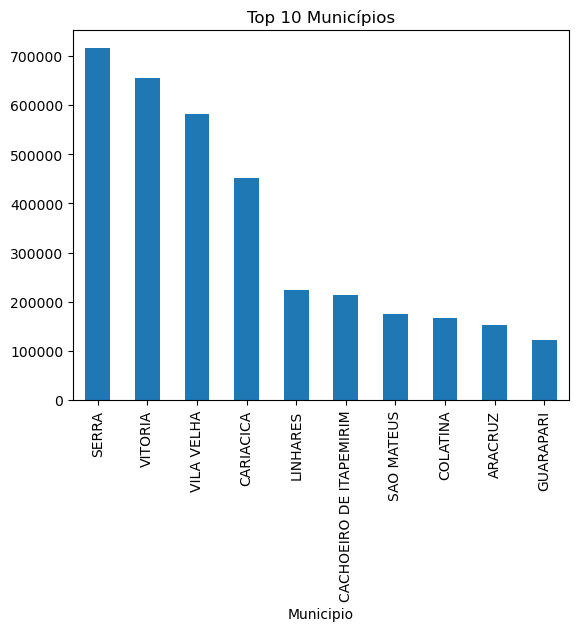

In [5]:
top_municipios = df['Municipio'].value_counts().head(10)

print(top_municipios)

top_municipios.plot(kind='bar')
plt.title('Top 10 Municípios')
plt.show()

Observa-se que o município de Serra possui o maior número de notificações, seguido por Vitória e Vila Velha, concentrando a maior parte dos casos nos centros urbanos. Nos demais municípios, há uma redução gradual nas notificações.

### Exercício 4 — Distribuição por Sexo
Análise da distribuição de casos por sexo.

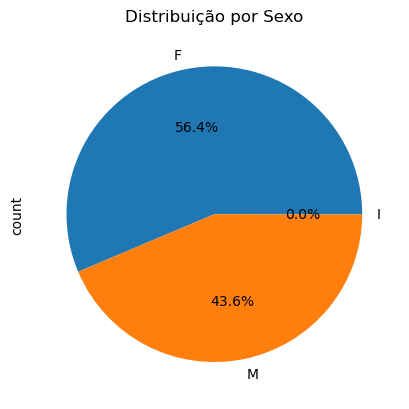

In [7]:
sexo = df['Sexo'].value_counts()

sexo.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribuição por Sexo')
plt.show()

Observa-se que o sexo feminino concentra a maior parte das notificações, com cerca de 56%, enquanto o masculino representa aproximadamente 44%, e a categoria "Ignorado" é praticamente irrelevante.

### Exercício 5 — Faixa Etária
Distribuição dos casos por faixa etária.

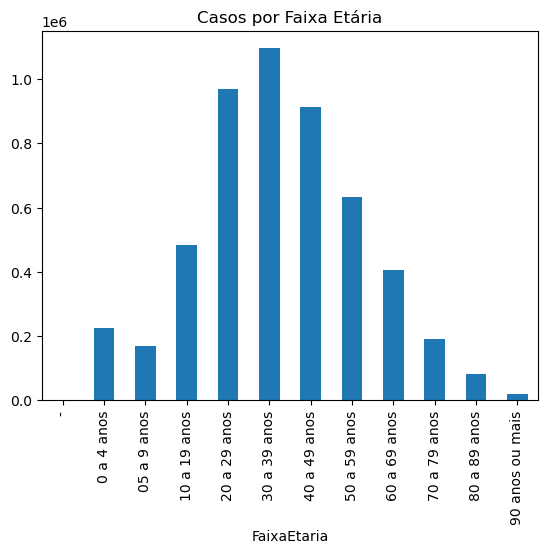

In [9]:
faixa = df['FaixaEtaria'].value_counts().sort_index()

faixa.plot(kind='bar')
plt.title('Casos por Faixa Etária')
plt.show()

Observa-se que a faixa etária de 30 a 39 anos concentra o maior número de notificações, seguida pelas faixas de 20 a 29 e 40 a 49 anos, indicando maior incidência na população adulta. Já crianças e idosos apresentam menor número de casos.

### Exercício 6 — Taxa de Letalidade
Cálculo da taxa de letalidade entre os casos confirmados.

In [10]:
confirmados = df[df['Classificacao'] == 'Confirmados']

total = len(confirmados)
obitos = len(confirmados[confirmados['Evolucao'] == 'Óbito pelo COVID-19'])

taxa = (obitos / total) * 100

print(f'Total confirmados: {total}')
print(f'Óbitos: {obitos}')
print(f'Taxa de letalidade: {taxa:.2f}%')

Total confirmados: 1398338
Óbitos: 15288
Taxa de letalidade: 1.09%


A taxa de letalidade foi de aproximadamente 1,09%, indicando que a maioria dos casos confirmados não evoluiu para óbito, possivelmente devido a fatores como atendimento médico, vacinação e características da população.

### Exercício 7 — Sintomas mais Frequentes
Análise dos sintomas mais comuns.

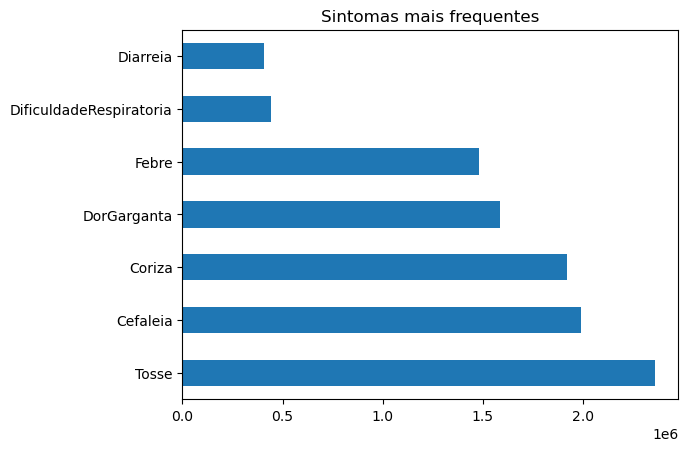

In [11]:
sintomas = ['Febre', 'DificuldadeRespiratoria', 'Tosse', 'Coriza', 'DorGarganta', 'Diarreia', 'Cefaleia']

contagem = {}

for s in sintomas:
    contagem[s] = (df[s] == 'Sim').sum()

serie = pd.Series(contagem).sort_values(ascending=False)

serie.plot(kind='barh')
plt.title('Sintomas mais frequentes')
plt.show()

Observa-se que a tosse é o sintoma mais frequente, seguida por cefaleia e coriza, enquanto dor de garganta e febre também aparecem com relevância; já dificuldade respiratória e diarreia são menos comuns.

### Exercício 8 — Comorbidades nos Óbitos
Análise das comorbidades mais presentes nos óbitos.

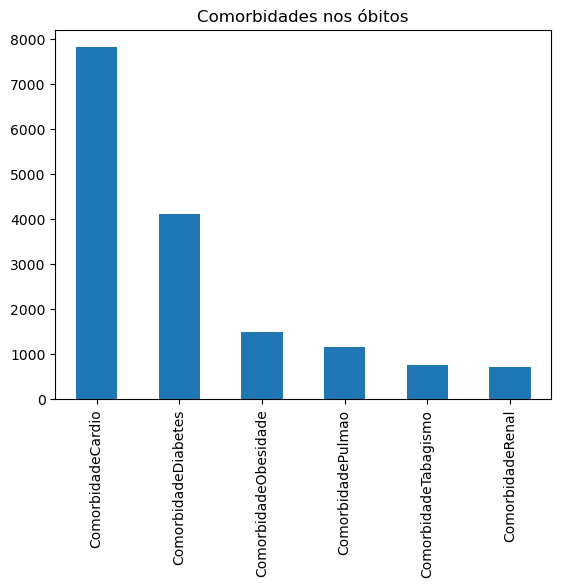

In [12]:
obitos = df[df['Evolucao'] == 'Óbito pelo COVID-19']

comorbidades = ['ComorbidadePulmao', 'ComorbidadeCardio', 'ComorbidadeRenal',
                'ComorbidadeDiabetes', 'ComorbidadeTabagismo', 'ComorbidadeObesidade']

contagem = {}

for c in comorbidades:
    contagem[c] = (obitos[c] == 'Sim').sum()

serie = pd.Series(contagem).sort_values(ascending=False)

serie.plot(kind='bar')
plt.title('Comorbidades nos óbitos')
plt.show()

Observa-se que a comorbidade cardíaca é a mais frequente entre os óbitos, seguida pela diabetes, enquanto as demais aparecem com menor ocorrência, indicando que doenças crônicas aumentam o risco de agravamento e óbito.

### Exercício 9 — Evolução Temporal
Análise da evolução das notificações ao longo do tempo.

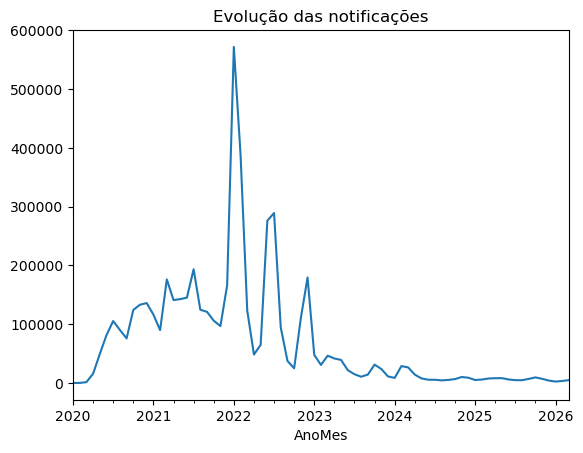

In [13]:
df['DataNotificacao'] = pd.to_datetime(df['DataNotificacao'])
df['AnoMes'] = df['DataNotificacao'].dt.to_period('M')

evolucao = df.groupby('AnoMes').size()

evolucao.plot(kind='line')
plt.title('Evolução das notificações')
plt.show()

A evolução das notificações mostra crescimento em 2020 e 2021, com pico no início de 2022, seguido de queda e pequenas oscilações, indicando ondas da pandemia ao longo do tempo.

### Exercício 10 — Tabela Cruzada
Análise cruzada entre municípios e evolução dos casos.

In [15]:
top5 = df['Municipio'].value_counts().head(5).index

df_top = df[df['Municipio'].isin(top5)]

tabela = pd.crosstab(df_top['Municipio'], df_top['Evolucao'])

print(tabela)

Evolucao         -    Cura  Ignorado  Óbito pelo COVID-19  \
Municipio                                                   
CARIACICA   210578   96906    142612                 1644   
LINHARES        70   65673    158467                  523   
SERRA        73166  157692    482250                 1821   
VILA VELHA    4364  155457    419751                 2082   
VITORIA      63335  161034    429430                 1493   

Evolucao    Óbito por outras causas  
Municipio                            
CARIACICA                       944  
LINHARES                         67  
SERRA                          1091  
VILA VELHA                     1044  
VITORIA                         845  


A tabela cruzada mostra que, nos principais municípios, a maioria dos casos evoluiu para cura, enquanto os óbitos estão presentes em todos, com maiores valores nas cidades mais populosas, indicando predominância de recuperação apesar do alto número de casos.